# Scratch code for scoring 

We start with loading data via O-NET and looking at how some SOCs are structured, and then come up with scoring mechanisms for the same.

In [ ]:
#|hide
import nblite; from nbdev.showdoc import show_doc; nblite.nbl_export()

/Users/bhargav/adu_dev/aisi-economy-index/.venv/lib/python3.11/site-packages/nbformat/__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)


In [ ]:
import aisi_economy_index as proj
from aisi_economy_index import const

In [ ]:
import json
import asyncio
from typing import Optional, Tuple, Dict, Any, List
import adulib.llm as llm
import inspect

In [ ]:
from dotenv import load_dotenv

load_dotenv() 

True

In [ ]:
from pydantic import BaseModel, ValidationError, conint, confloat


In [ ]:
from pathlib import Path


In [ ]:
BASE_DIR = Path("/Users/bhargav/adu_dev/aisi-economy-index/aisi_economy_index/store/data/db_30_0_excel")
OUT_DIR = Path(str(const.data_path)) / "eval_dfs"
OUT_DIR.mkdir(exist_ok=True)

## Exploring O-NET by SOC code

In [ ]:
import os
import pandas as pd

EVAL_DF_DIR = const.data_path / "eval_dfs"

def _load_csv(path):
    if not os.path.exists(path):
        # Return empty DF with no error if a file is missing
        return pd.DataFrame()
    return pd.read_csv(path)

# Load the new eval tables
skills_eval     = _load_csv(f"{EVAL_DF_DIR}/skills_eval.csv")
abilities_eval  = _load_csv(f"{EVAL_DF_DIR}/abilities_eval.csv")
knowledge_eval  = _load_csv(f"{EVAL_DF_DIR}/knowledge_eval.csv")
gwas_eval       = _load_csv(f"{EVAL_DF_DIR}/gwas_eval.csv")      # was activities_eval
dwas_eval       = _load_csv(f"{EVAL_DF_DIR}/dwas_eval.csv")      # new
tasks_eval      = _load_csv(f"{EVAL_DF_DIR}/tasks_eval.csv")

# Bundle for pipelines (with a compat alias for activities_eval → gwas_eval)
eval_dfs = dict(
    skills_eval=skills_eval,
    abilities_eval=abilities_eval,
    knowledge_eval=knowledge_eval,
    gwas_eval=gwas_eval,
    dwas_eval=dwas_eval,
    tasks_eval=tasks_eval,

    # Backwards-compat key (some old code may still look for this)
    activities_eval=gwas_eval,
)


In [ ]:
abilities_eval

,OnetSocCode,Title,ElementID,ability,importance,level
0,11-1011.00,Chief Executives,1.A.1.a.1,Oral Comprehension,4.62,4.88
1,11-1011.00,Chief Executives,1.A.1.a.2,Written Comprehension,4.25,4.88
2,11-1011.00,Chief Executives,1.A.1.a.3,Oral Expression,4.50,4.88
3,11-1011.00,Chief Executives,1.A.1.a.4,Written Expression,4.12,4.75
4,11-1011.00,Chief Executives,1.A.1.b.1,Fluency of Ideas,3.88,4.62
...,...,...,...,...,...,...
46483,53-7121.00,"Tank Car, Truck, and Ship Loaders",1.A.4.b.1,Hearing Sensitivity,3.00,3.00
46484,53-7121.00,"Tank Car, Truck, and Ship Loaders",1.A.4.b.2,Auditory Attention,3.00,3.00
46485,53-7121.00,"Tank Car, Truck, and Ship Loaders",1.A.4.b.3,Sound Localization,2.00,2.00
46486,53-7121.00,"Tank Car, Truck, and Ship Loaders",1.A.4.b.4,Speech Recognition,3.12,2.75


In [ ]:
skills_eval

,OnetSocCode,Title,ElementID,skill,importance,level
0,11-1011.00,Chief Executives,2.A.1.a,Reading Comprehension,4.12,4.62
1,11-1011.00,Chief Executives,2.A.1.b,Active Listening,4.00,4.75
2,11-1011.00,Chief Executives,2.A.1.c,Writing,4.12,4.38
3,11-1011.00,Chief Executives,2.A.1.d,Speaking,4.25,4.75
4,11-1011.00,Chief Executives,2.A.1.e,Mathematics,3.25,3.50
...,...,...,...,...,...,...
31285,53-7121.00,"Tank Car, Truck, and Ship Loaders",2.B.4.h,Systems Evaluation,2.12,2.12
31286,53-7121.00,"Tank Car, Truck, and Ship Loaders",2.B.5.a,Time Management,3.12,2.88
31287,53-7121.00,"Tank Car, Truck, and Ship Loaders",2.B.5.b,Management of Financial Resources,2.00,1.12
31288,53-7121.00,"Tank Car, Truck, and Ship Loaders",2.B.5.c,Management of Material Resources,2.00,1.88


In [ ]:
knowledge_eval

,OnetSocCode,Title,ElementID,knowledge_area,importance,level
0,11-1011.00,Chief Executives,2.C.1.a,Administration and Management,4.78,6.50
1,11-1011.00,Chief Executives,2.C.1.b,Administrative,2.42,2.69
2,11-1011.00,Chief Executives,2.C.1.c,Economics and Accounting,4.04,4.98
3,11-1011.00,Chief Executives,2.C.1.d,Sales and Marketing,3.81,5.04
4,11-1011.00,Chief Executives,2.C.1.e,Customer and Personal Service,4.39,5.94
...,...,...,...,...,...,...
29497,53-7121.00,"Tank Car, Truck, and Ship Loaders",2.C.7.e,Philosophy and Theology,1.19,0.33
29498,53-7121.00,"Tank Car, Truck, and Ship Loaders",2.C.8.a,Public Safety and Security,3.15,2.61
29499,53-7121.00,"Tank Car, Truck, and Ship Loaders",2.C.8.b,Law and Government,1.81,1.52
29500,53-7121.00,"Tank Car, Truck, and Ship Loaders",2.C.9.a,Telecommunications,2.13,0.93


## Felten Approach

In [ ]:
import pandas as pd
import numpy as np
from typing import Dict, Tuple, Optional
from pathlib import Path


In [ ]:
FELTEN_DATA_PATH = const.data_path / "felten-data"


In [ ]:
felten_appendix = pd.ExcelFile(FELTEN_DATA_PATH / "AIOE_DataAppendix.xlsx")


In [ ]:
# Load relatedness matrix
ability_app_matrix_raw = pd.read_excel(felten_appendix, sheet_name="Appendix D")
ability_app_matrix_raw = ability_app_matrix_raw.rename(columns={"Unnamed: 0": "ability"})
ability_app_matrix_raw = ability_app_matrix_raw.set_index("ability")

In [ ]:
# Standardize column names to match code conventions
COLUMN_MAPPING = {
    "Abstract Strategy Games": "abstract_strategy_games",
    "Real-Time Video Games": "realtime_video_games",
    "Image Recognition": "image_recognition",
    "Visual Question Answering": "visual_question_answering",
    "Generating Images": "image_generation",
    "Reading Comprehension": "reading_comprehension",
    "Language Modeling": "language_modeling",
    "Translation": "translation",
    "Speech Recognition": "speech_recognition",
    "Instrumental Track Recognition": "instrumental_track_recognition",
}
ability_app_matrix = ability_app_matrix_raw.rename(columns=COLUMN_MAPPING)

# Application list (order matters for consistency)
APPLICATIONS = list(COLUMN_MAPPING.values())

print(f"Loaded ability × application matrix: {ability_app_matrix.shape}")
print(f"Abilities: {len(ability_app_matrix)}")
print(f"Applications: {APPLICATIONS}")

Loaded ability × application matrix: (52, 10)
Abilities: 52
Applications: ['abstract_strategy_games', 'realtime_video_games', 'image_recognition', 'visual_question_answering', 'image_generation', 'reading_comprehension', 'language_modeling', 'translation', 'speech_recognition', 'instrumental_track_recognition']


In [ ]:
# Load Felten's original occupation-level scores for comparison
felten_aioe = pd.read_excel(felten_appendix, sheet_name="Appendix A")
felten_aioe = felten_aioe.rename(columns={"SOC Code": "soc_code", "Occupation Title": "title", "AIOE": "felten_aioe"})

# Load language modeling and image generation specific scores
lm_aioe = pd.read_excel(FELTEN_DATA_PATH / "Language Modeling AIOE and AIIE.xlsx", sheet_name="LM AIOE")
lm_aioe = lm_aioe.rename(columns={"SOC Code": "soc_code", "Occupation Title": "title", "Language Modeling AIOE": "lm_aioe"})

ig_aioe = pd.read_excel(FELTEN_DATA_PATH / "Image Generation AIOE and AIIE.xlsx", sheet_name="IG AIOE")
ig_aioe = ig_aioe.rename(columns={"SOC Code": "soc_code", "Occupation Title": "title", "Image Generation AIOE": "ig_aioe"})

# Merge reference scores
felten_reference = felten_aioe.merge(lm_aioe[["soc_code", "lm_aioe"]], on="soc_code", how="left")
felten_reference = felten_reference.merge(ig_aioe[["soc_code", "ig_aioe"]], on="soc_code", how="left")

print(f"Loaded Felten reference scores: {len(felten_reference)} occupations")

Loaded Felten reference scores: 774 occupations


In [ ]:
felten_reference

,soc_code,title,felten_aioe,lm_aioe,ig_aioe
0,11-1011,Chief Executives,1.334246,1.308912,1.309602
1,11-1021,General and Operations Managers,0.574877,0.677615,0.231884
2,11-2011,Advertising and Promotions Managers,1.294387,1.217224,1.614598
3,11-2021,Marketing Managers,1.315032,1.203774,1.610358
4,11-2022,Sales Managers,1.266280,1.293821,1.009998
...,...,...,...,...,...
769,53-7072,"Pump Operators, Except Wellhead Pumpers",-0.842293,-0.971658,-0.533343
770,53-7073,Wellhead Pumpers,-1.091197,-1.099431,-0.952534
771,53-7081,Refuse and Recyclable Material Collectors,-1.283373,-1.262763,-0.904922
772,53-7111,Shuttle Car Operators,-1.351998,-1.497306,-0.783455


In [ ]:
PROGRESS_SCENARIOS = {
    # Felten's original: equal weighting across all 10 applications
    "felten_original": {
        "abstract_strategy_games": 1.0,
        "realtime_video_games": 1.0,
        "image_recognition": 1.0,
        "visual_question_answering": 1.0,
        "image_generation": 1.0,
        "reading_comprehension": 1.0,
        "language_modeling": 1.0,
        "translation": 1.0,
        "speech_recognition": 1.0,
        "instrumental_track_recognition": 1.0,
    },
    # Updated for late 2024/2025 frontier capabilities (your extension)
    "baseline_2025": {
        "abstract_strategy_games": 1.0,   # Already saturated in 2021
        "realtime_video_games": 1.3,      # Improved
        "image_recognition": 1.1,         # Improved
        "visual_question_answering": 1.5, # Significant improvement
        "image_generation": 1.5,          # Major leap (DALL-E, Midjourney)
        "reading_comprehension": 1.4,     # Improved
        "language_modeling": 1.5,         # Massive leap (GPT-4, Claude)
        "translation": 1.3,               # Improved
        "speech_recognition": 1.1,        # Already good, modest improvement
        "instrumental_track_recognition": 1.2,
    },
    # Conservative lower-bound estimates (your extension)
    "conservative_2025": {
        "abstract_strategy_games": 0.90,
        "realtime_video_games": 0.50,
        "image_recognition": 0.82,
        "visual_question_answering": 0.72,
        "image_generation": 0.78,
        "reading_comprehension": 0.82,
        "language_modeling": 0.88,
        "translation": 0.78,
        "speech_recognition": 0.88,
        "instrumental_track_recognition": 0.60,
    },
    # GenAI only (Felten 2023 style - isolates LLM + image gen)
    "genai_only": {
        "abstract_strategy_games": 0.0,
        "realtime_video_games": 0.0,
        "image_recognition": 0.0,
        "visual_question_answering": 0.0,
        "image_generation": 1.0,
        "reading_comprehension": 0.0,
        "language_modeling": 1.0,
        "translation": 0.0,
        "speech_recognition": 0.0,
        "instrumental_track_recognition": 0.0,
    },
}

In [ ]:
def get_progress(scenario: str = "baseline_2025") -> Dict[str, float]:
    """Get progress vector for a given scenario."""
    if scenario not in PROGRESS_SCENARIOS:
        raise ValueError(f"Unknown scenario: {scenario}. Choose from: {list(PROGRESS_SCENARIOS.keys())}")
    return PROGRESS_SCENARIOS[scenario]

# Display scenarios
progress_df = pd.DataFrame(PROGRESS_SCENARIOS)
print("Progress Vector Scenarios:")
progress_df

Progress Vector Scenarios:


,felten_original,baseline_2025,conservative_2025,genai_only
abstract_strategy_games,1.0,1.0,0.90,0.0
realtime_video_games,1.0,1.3,0.50,0.0
image_recognition,1.0,1.1,0.82,0.0
visual_question_answering,1.0,1.5,0.72,0.0
image_generation,1.0,1.5,0.78,1.0
reading_comprehension,1.0,1.4,0.82,0.0
language_modeling,1.0,1.5,0.88,1.0
translation,1.0,1.3,0.78,0.0
speech_recognition,1.0,1.1,0.88,0.0
instrumental_track_recognition,1.0,1.2,0.60,0.0


In [ ]:
def compute_ability_exposure(
    ability_app_matrix: pd.DataFrame,
    progress: Dict[str, float],
) -> pd.Series:
    """
    Compute AI exposure for each ability.
    
    Formula: E[ability] = Σ (Relatedness[ability,app] × Progress[app]) / Σ Progress[app]
    
    This is a weighted average where progress scores act as weights.
    """
    # Get applications present in both matrix and progress
    apps = [a for a in progress.keys() if a in ability_app_matrix.columns]
    
    # Create progress series
    P = pd.Series({app: progress[app] for app in apps})
    
    # Get relatedness matrix for these applications
    A = ability_app_matrix[apps]
    
    # Weighted average: (A @ P) / sum(P)
    # This weights each application's relatedness by how good AI is at that application
    ability_exposure = (A @ P) / P.sum()
    ability_exposure.name = "ability_exposure"
    
    return ability_exposure


In [ ]:
def compute_occupation_weights(
    onet_abilities_df: pd.DataFrame,
    ability_col: str = "ability",
    importance_col: str = "importance",
    level_col: str = "level",
    soc_col: str = "OnetSocCode",
    importance_max: float = 5.0,
    level_max: float = 7.0,
    alpha: float = 0.5,
) -> pd.DataFrame:
    """
    Create occupation × ability weight matrix from O*NET importance/level scores.
    
    Weight = α × (importance/5) + (1-α) × (level/7)
    
    Returns a pivot table: rows = occupations, columns = abilities
    """
    df = onet_abilities_df.copy()
    
    # Normalize importance and level to [0, 1]
    imp_norm = (df[importance_col] / importance_max).clip(0, 1)
    lvl_norm = (df[level_col] / level_max).clip(0, 1)
    
    # Combined weight
    df["weight"] = alpha * imp_norm + (1 - alpha) * lvl_norm
    
    # Pivot to occupation × ability matrix
    weight_matrix = df.pivot_table(
        index=soc_col,
        columns=ability_col,
        values="weight",
        aggfunc="first",
    ).fillna(0.0)
    
    return weight_matrix

In [ ]:
def compute_occupation_exposure(
    weight_matrix: pd.DataFrame,
    ability_exposure: pd.Series,
) -> pd.Series:
    """
    Compute occupation-level AI exposure.
    
    Formula: E[occ] = Σ (Weight[occ,ability] × E[ability]) / Σ Weight[occ,ability]
    
    This aggregates ability exposures weighted by how important each ability is to the occupation.
    """
    # Align abilities between weight matrix and exposure scores
    common_abilities = weight_matrix.columns.intersection(ability_exposure.index)
    
    if len(common_abilities) == 0:
        raise ValueError("No common abilities between weight matrix and ability exposure")
    
    print(f"  Using {len(common_abilities)} abilities for exposure calculation")
    
    W = weight_matrix[common_abilities]
    E = ability_exposure[common_abilities]
    
    # Weighted average per occupation
    numerator = W @ E  # Sum of (weight × exposure) for each occupation
    denominator = W.sum(axis=1).replace(0, np.nan)  # Sum of weights
    
    occupation_exposure = numerator / denominator
    occupation_exposure.name = "exposure"
    
    return occupation_exposure

In [ ]:
def run_abilities_pipeline(
    abilities_df: pd.DataFrame,
    ability_app_matrix: pd.DataFrame,
    progress_scenario: str = "baseline_2025",
    verbose: bool = True,
) -> Tuple[pd.DataFrame, pd.Series, Dict]:
    """
    Run the complete Felten-style abilities-only exposure pipeline.
    
    Parameters
    ----------
    abilities_df : O*NET abilities data with columns [OnetSocCode, Title, ability, importance, level]
    ability_app_matrix : Felten's 52 × 10 ability-application relatedness matrix
    progress_scenario : Which progress vector to use
    verbose : Print progress updates
    
    Returns
    -------
    Tuple of (occupation_results_df, ability_exposure_series, metadata_dict)
    """
    if verbose:
        print("=" * 70)
        print(f"FELTEN ABILITIES-ONLY PIPELINE (scenario: {progress_scenario})")
        print("=" * 70)
    
    # Step 1: Get progress vector
    progress = get_progress(progress_scenario)
    if verbose:
        print(f"\nStep 1: Using progress scenario '{progress_scenario}'")
        active_apps = [k for k, v in progress.items() if v > 0]
        print(f"  Active applications: {len(active_apps)}")
    
    # Step 2: Compute ability-level exposure
    ability_exposure = compute_ability_exposure(ability_app_matrix, progress)
    if verbose:
        print(f"\nStep 2: Computed ability exposure for {len(ability_exposure)} abilities")
        print(f"  Mean: {ability_exposure.mean():.4f}, Std: {ability_exposure.std():.4f}")
        print(f"  Top 3: {ability_exposure.nlargest(3).index.tolist()}")
        print(f"  Bottom 3: {ability_exposure.nsmallest(3).index.tolist()}")
    
    # Step 3: Build occupation weight matrix
    weight_matrix = compute_occupation_weights(
        abilities_df, 
        ability_col="ability",
        soc_col="OnetSocCode"
    )
    if verbose:
        print(f"\nStep 3: Built weight matrix: {weight_matrix.shape[0]} occupations × {weight_matrix.shape[1]} abilities")
    
    # Step 4: Compute occupation exposure
    occupation_exposure = compute_occupation_exposure(weight_matrix, ability_exposure)
    if verbose:
        print(f"\nStep 4: Computed exposure for {len(occupation_exposure)} occupations")
        print(f"  Mean: {occupation_exposure.mean():.4f}, Std: {occupation_exposure.std():.4f}")
    
    # Step 5: Build output DataFrame
    titles = abilities_df[["OnetSocCode", "Title"]].drop_duplicates().set_index("OnetSocCode")["Title"]
    
    output = pd.DataFrame({
        "exposure": occupation_exposure,
    })
    output["title"] = output.index.map(titles)
    output["rank"] = output["exposure"].rank(ascending=False, method="min").astype(int)
    output["percentile"] = output["exposure"].rank(pct=True) * 100
    
    # Reorder columns
    output = output[["rank", "title", "exposure", "percentile"]].sort_values("rank")
    output.index.name = "soc_code"
    
    if verbose:
        print(f"\nStep 5: Output ready")
        print("=" * 70)
    
    metadata = {
        "scenario": progress_scenario,
        "progress": progress,
        "n_occupations": len(output),
        "n_abilities": len(ability_exposure),
        "exposure_mean": occupation_exposure.mean(),
        "exposure_std": occupation_exposure.std(),
    }
    
    return output, ability_exposure, metadata

print("Pipeline function defined")

Pipeline function defined


In [ ]:

SCENARIO = "baseline_2025"  # Options: "felten_original", "baseline_2025", "conservative_2025", "genai_only"

# Run pipeline (assumes abilities_eval is already loaded from earlier cells)
output_df, ability_exp, metadata = run_abilities_pipeline(
    abilities_df=abilities_eval,
    ability_app_matrix=ability_app_matrix,
    progress_scenario=SCENARIO,
    verbose=True,
)

FELTEN ABILITIES-ONLY PIPELINE (scenario: baseline_2025)

Step 1: Using progress scenario 'baseline_2025'
  Active applications: 10

Step 2: Computed ability exposure for 52 abilities
  Mean: 0.5423, Std: 0.1754
  Top 3: ['Information Ordering', 'Memorization', 'Speed of Closure']
  Bottom 3: ['Trunk Strength', 'Explosive Strength', 'Dynamic Strength']

Step 3: Built weight matrix: 894 occupations × 52 abilities
  Using 51 abilities for exposure calculation

Step 4: Computed exposure for 894 occupations
  Mean: 0.5827, Std: 0.0301

Step 5: Output ready


In [ ]:
print("=" * 80)
print("TOP 25 MOST EXPOSED OCCUPATIONS")
print("=" * 80)
output_df.head(25)

# %%
# Bottom 25 least exposed occupations
print("=" * 80)
print("BOTTOM 25 LEAST EXPOSED OCCUPATIONS")
print("=" * 80)
output_df.tail(25).iloc[::-1]

# %%
# Ability-level exposure scores
print("=" * 80)
print("ABILITY-LEVEL EXPOSURE SCORES")
print("=" * 80)
ability_exp_df = ability_exp.reset_index()
ability_exp_df.columns = ["ability", "exposure"]
ability_exp_df = ability_exp_df.sort_values("exposure", ascending=False)
ability_exp_df["rank"] = range(1, len(ability_exp_df) + 1)
ability_exp_df[["rank", "ability", "exposure"]]

TOP 25 MOST EXPOSED OCCUPATIONS
BOTTOM 25 LEAST EXPOSED OCCUPATIONS
ABILITY-LEVEL EXPOSURE SCORES


,rank,ability,exposure
19,1,Information Ordering,0.877907
22,2,Memorization,0.838760
41,3,Speed of Closure,0.781550
12,4,Flexibility of Closure,0.779690
2,5,Category Flexibility,0.767364
30,6,Perceptual Speed,0.760465
36,7,Selective Attention,0.742016
4,8,Deductive Reasoning,0.729380
18,9,Inductive Reasoning,0.713023
40,10,Speech Recognition,0.711938


In [ ]:
output_df = output_df.reset_index(names="soc_code")


In [ ]:
output_df["soc_code_clean"] = output_df["soc_code"].str.replace(r"\.0+$", "", regex=True)
felten_reference["soc_code_clean"] = felten_reference["soc_code"].astype(str).str.strip()


In [ ]:
comparison = output_df.merge(
    felten_reference[["soc_code_clean", "felten_aioe", "lm_aioe", "ig_aioe"]],
    on="soc_code_clean",
    how="inner"
)


In [ ]:
# Compute correlation
corr_overall = comparison["exposure"].corr(comparison["felten_aioe"])
corr_lm = comparison["exposure"].corr(comparison["lm_aioe"])
corr_ig = comparison["exposure"].corr(comparison["ig_aioe"])

print("=" * 80)
print("CORRELATION WITH FELTEN'S PUBLISHED SCORES")
print("=" * 80)
print(f"Correlation with overall AIOE:      {corr_overall:.4f}")
print(f"Correlation with LM-specific AIOE:  {corr_lm:.4f}")
print(f"Correlation with IG-specific AIOE:  {corr_ig:.4f}")
print(f"\nNote: Our scores use a different progress vector than Felten's original,")
print("so correlation < 1.0 is expected. High correlation validates the methodology.")

CORRELATION WITH FELTEN'S PUBLISHED SCORES
Correlation with overall AIOE:      0.9843
Correlation with LM-specific AIOE:  0.9661
Correlation with IG-specific AIOE:  0.8445

Note: Our scores use a different progress vector than Felten's original,
so correlation < 1.0 is expected. High correlation validates the methodology.


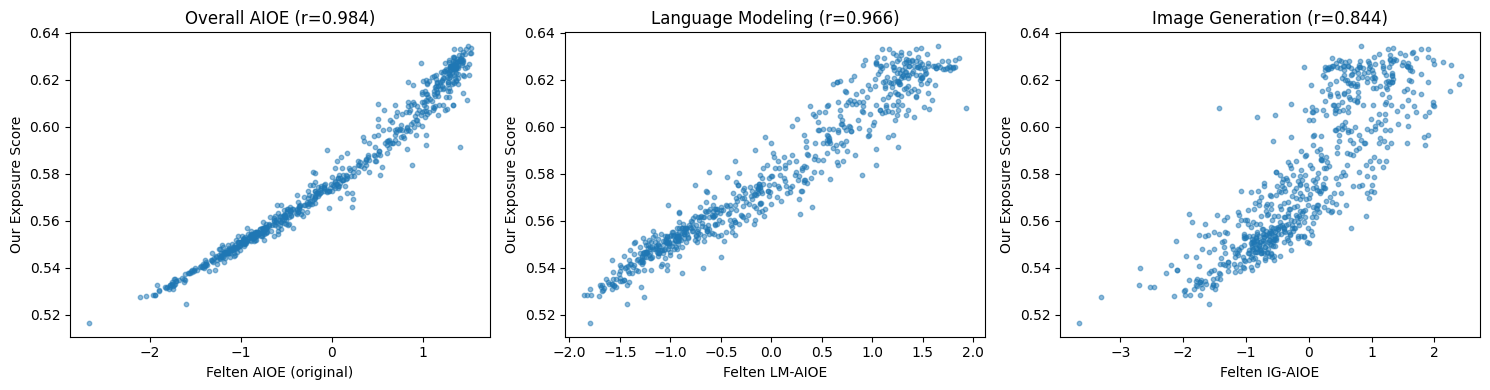

Plot saved to felten_comparison.png


In [ ]:
try:
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    axes[0].scatter(comparison["felten_aioe"], comparison["exposure"], alpha=0.5, s=10)
    axes[0].set_xlabel("Felten AIOE (original)")
    axes[0].set_ylabel("Our Exposure Score")
    axes[0].set_title(f"Overall AIOE (r={corr_overall:.3f})")
    
    axes[1].scatter(comparison["lm_aioe"], comparison["exposure"], alpha=0.5, s=10)
    axes[1].set_xlabel("Felten LM-AIOE")
    axes[1].set_ylabel("Our Exposure Score")
    axes[1].set_title(f"Language Modeling (r={corr_lm:.3f})")
    
    axes[2].scatter(comparison["ig_aioe"], comparison["exposure"], alpha=0.5, s=10)
    axes[2].set_xlabel("Felten IG-AIOE")
    axes[2].set_ylabel("Our Exposure Score")
    axes[2].set_title(f"Image Generation (r={corr_ig:.3f})")
    
    plt.tight_layout()
    plt.savefig("felten_comparison.png", dpi=150)
    plt.show()
    print("Plot saved to felten_comparison.png")
except ImportError:
    print("matplotlib not available, skipping plot")

In [ ]:
# Run all scenarios and compare
scenarios_to_run = ["felten_original", "baseline_2025", "conservative_2025", "genai_only"]
all_results = {}

for scenario in scenarios_to_run:
    result_df, _, _ = run_abilities_pipeline(
        abilities_df=abilities_eval,
        ability_app_matrix=ability_app_matrix,
        progress_scenario=scenario,
        verbose=False,
    )
    all_results[scenario] = result_df["exposure"].values  # Use .values to drop index

# Combine into single DataFrame
comparison_df = pd.DataFrame(all_results)
comparison_df["title"] = output_df["title"].values  # Use .values here too
comparison_df["soc_code"] = output_df["soc_code"].values

  Using 51 abilities for exposure calculation
  Using 51 abilities for exposure calculation
  Using 51 abilities for exposure calculation
  Using 51 abilities for exposure calculation


In [ ]:
comparison_df

,felten_original,baseline_2025,conservative_2025,genai_only,title,soc_code
0,0.634413,0.634377,0.634234,0.606602,"Judges, Magistrate Judges, and Magistrates",23-1023.00
1,0.634087,0.633810,0.633416,0.605519,Investment Fund Managers,11-3031.03
2,0.633659,0.633489,0.633211,0.604133,Genetic Counselors,29-9092.00
3,0.633306,0.633282,0.633112,0.603905,Industrial-Organizational Psychologists,19-3032.00
4,0.633289,0.633189,0.633092,0.603822,Mathematicians,15-2021.00
...,...,...,...,...,...,...
889,0.529442,0.528130,0.524839,0.485347,Reinforcing Iron and Rebar Workers,47-2171.00
890,0.529152,0.528016,0.524514,0.485212,"Helpers--Painters, Paperhangers, Plasterers, a...",47-3014.00
891,0.528166,0.527427,0.524452,0.484455,Exercise Trainers and Group Fitness Instructors,39-9031.00
892,0.525644,0.524444,0.520921,0.482189,"Farmworkers and Laborers, Crop, Nursery, and G...",45-2092.00


In [ ]:
# Save Felten exposure scores to SOC_codes folder
import os
os.makedirs('SOC_codes', exist_ok=True)

# Save the comparison DataFrame with Felten scores by SOC
comparison_df.to_csv('SOC_codes/felten_scores_by_soc.csv', index=False)
print(f"Saved {len(comparison_df)} SOC codes to SOC_codes/felten_scores_by_soc.csv")
comparison_df.head()

Saved 894 SOC codes to SOC_codes/felten_scores_by_soc.csv


,felten_original,baseline_2025,conservative_2025,genai_only,title,soc_code
0,0.634413,0.634377,0.634234,0.606602,"Judges, Magistrate Judges, and Magistrates",23-1023.00
1,0.634087,0.633810,0.633416,0.605519,Investment Fund Managers,11-3031.03
2,0.633659,0.633489,0.633211,0.604133,Genetic Counselors,29-9092.00
3,0.633306,0.633282,0.633112,0.603905,Industrial-Organizational Psychologists,19-3032.00
4,0.633289,0.633189,0.633092,0.603822,Mathematicians,15-2021.00


In [ ]:
# %%
# Save main output
output_df.to_csv("occupation_exposure_abilities.csv")
print("Saved: occupation_exposure_abilities.csv")

# Save ability-level scores
ability_exp_df.to_csv("ability_exposure_scores.csv", index=False)
print("Saved: ability_exposure_scores.csv")

# Save multi-scenario comparison
comparison_df.to_csv("occupation_exposure_all_scenarios.csv")
print("Saved: occupation_exposure_all_scenarios.csv")

print("\nAll results saved!")

Saved: occupation_exposure_abilities.csv
Saved: ability_exposure_scores.csv
Saved: occupation_exposure_all_scenarios.csv

All results saved!


## Extensions to Skills and Knowledge

In [ ]:
# ## Cell 10b: Create Skills × Applications Matrix (Manual Approximation)
# 
# This creates a relatedness matrix mapping 35 O*NET skills to 10 AI applications.
# Values range from 0 (no relation) to 1 (high relation).
# 
# **Note:** These are LLM-estimated values. For academic work, consider:
# - MTurk/Prolific survey validation
# - LLM-assisted rating with human review
# - Expert panel consensus

# %%
# AI Applications (must match Felten's 10)
AI_APPLICATIONS = [
    "abstract_strategy_games",
    "realtime_video_games",
    "image_recognition",
    "visual_question_answering",
    "image_generation",
    "reading_comprehension",
    "language_modeling",
    "translation",
    "speech_recognition",
    "instrumental_track_recognition",
]

# Skills × Applications relatedness matrix
# Format: skill_name -> {application: relatedness_score}
SKILLS_APP_RELATEDNESS = {
    # Cognitive Skills
    "Active Learning": {
        "abstract_strategy_games": 0.3, "realtime_video_games": 0.2, "image_recognition": 0.3,
        "visual_question_answering": 0.4, "image_generation": 0.2, "reading_comprehension": 0.7,
        "language_modeling": 0.7, "translation": 0.5, "speech_recognition": 0.3, "instrumental_track_recognition": 0.1,
    },
    "Active Listening": {
        "abstract_strategy_games": 0.0, "realtime_video_games": 0.1, "image_recognition": 0.0,
        "visual_question_answering": 0.2, "image_generation": 0.0, "reading_comprehension": 0.4,
        "language_modeling": 0.5, "translation": 0.6, "speech_recognition": 0.9, "instrumental_track_recognition": 0.3,
    },
    "Complex Problem Solving": {
        "abstract_strategy_games": 0.8, "realtime_video_games": 0.5, "image_recognition": 0.3,
        "visual_question_answering": 0.6, "image_generation": 0.2, "reading_comprehension": 0.6,
        "language_modeling": 0.8, "translation": 0.4, "speech_recognition": 0.1, "instrumental_track_recognition": 0.1,
    },
    "Coordination": {
        "abstract_strategy_games": 0.3, "realtime_video_games": 0.6, "image_recognition": 0.2,
        "visual_question_answering": 0.2, "image_generation": 0.1, "reading_comprehension": 0.2,
        "language_modeling": 0.3, "translation": 0.2, "speech_recognition": 0.2, "instrumental_track_recognition": 0.1,
    },
    "Critical Thinking": {
        "abstract_strategy_games": 0.7, "realtime_video_games": 0.3, "image_recognition": 0.3,
        "visual_question_answering": 0.6, "image_generation": 0.2, "reading_comprehension": 0.8,
        "language_modeling": 0.8, "translation": 0.5, "speech_recognition": 0.2, "instrumental_track_recognition": 0.1,
    },
    # Technical Skills
    "Equipment Maintenance": {
        "abstract_strategy_games": 0.0, "realtime_video_games": 0.1, "image_recognition": 0.4,
        "visual_question_answering": 0.3, "image_generation": 0.1, "reading_comprehension": 0.3,
        "language_modeling": 0.3, "translation": 0.1, "speech_recognition": 0.1, "instrumental_track_recognition": 0.1,
    },
    "Equipment Selection": {
        "abstract_strategy_games": 0.1, "realtime_video_games": 0.1, "image_recognition": 0.3,
        "visual_question_answering": 0.3, "image_generation": 0.2, "reading_comprehension": 0.3,
        "language_modeling": 0.4, "translation": 0.1, "speech_recognition": 0.1, "instrumental_track_recognition": 0.1,
    },
    "Installation": {
        "abstract_strategy_games": 0.0, "realtime_video_games": 0.1, "image_recognition": 0.2,
        "visual_question_answering": 0.2, "image_generation": 0.1, "reading_comprehension": 0.3,
        "language_modeling": 0.3, "translation": 0.1, "speech_recognition": 0.1, "instrumental_track_recognition": 0.0,
    },
    "Instructing": {
        "abstract_strategy_games": 0.2, "realtime_video_games": 0.2, "image_recognition": 0.2,
        "visual_question_answering": 0.4, "image_generation": 0.3, "reading_comprehension": 0.5,
        "language_modeling": 0.8, "translation": 0.5, "speech_recognition": 0.5, "instrumental_track_recognition": 0.1,
    },
    "Judgment and Decision Making": {
        "abstract_strategy_games": 0.8, "realtime_video_games": 0.5, "image_recognition": 0.4,
        "visual_question_answering": 0.5, "image_generation": 0.2, "reading_comprehension": 0.6,
        "language_modeling": 0.7, "translation": 0.3, "speech_recognition": 0.2, "instrumental_track_recognition": 0.1,
    },
    "Learning Strategies": {
        "abstract_strategy_games": 0.4, "realtime_video_games": 0.3, "image_recognition": 0.3,
        "visual_question_answering": 0.4, "image_generation": 0.2, "reading_comprehension": 0.6,
        "language_modeling": 0.7, "translation": 0.4, "speech_recognition": 0.3, "instrumental_track_recognition": 0.1,
    },
    "Management of Financial Resources": {
        "abstract_strategy_games": 0.3, "realtime_video_games": 0.1, "image_recognition": 0.2,
        "visual_question_answering": 0.2, "image_generation": 0.1, "reading_comprehension": 0.5,
        "language_modeling": 0.6, "translation": 0.2, "speech_recognition": 0.1, "instrumental_track_recognition": 0.0,
    },
    "Management of Material Resources": {
        "abstract_strategy_games": 0.2, "realtime_video_games": 0.2, "image_recognition": 0.4,
        "visual_question_answering": 0.3, "image_generation": 0.1, "reading_comprehension": 0.3,
        "language_modeling": 0.4, "translation": 0.1, "speech_recognition": 0.1, "instrumental_track_recognition": 0.0,
    },
    "Management of Personnel Resources": {
        "abstract_strategy_games": 0.2, "realtime_video_games": 0.2, "image_recognition": 0.1,
        "visual_question_answering": 0.2, "image_generation": 0.1, "reading_comprehension": 0.4,
        "language_modeling": 0.5, "translation": 0.3, "speech_recognition": 0.3, "instrumental_track_recognition": 0.0,
    },
    "Mathematics": {
        "abstract_strategy_games": 0.7, "realtime_video_games": 0.3, "image_recognition": 0.3,
        "visual_question_answering": 0.4, "image_generation": 0.2, "reading_comprehension": 0.5,
        "language_modeling": 0.7, "translation": 0.3, "speech_recognition": 0.1, "instrumental_track_recognition": 0.1,
    },
    "Monitoring": {
        "abstract_strategy_games": 0.4, "realtime_video_games": 0.6, "image_recognition": 0.7,
        "visual_question_answering": 0.5, "image_generation": 0.1, "reading_comprehension": 0.4,
        "language_modeling": 0.4, "translation": 0.2, "speech_recognition": 0.4, "instrumental_track_recognition": 0.3,
    },
    "Negotiation": {
        "abstract_strategy_games": 0.4, "realtime_video_games": 0.1, "image_recognition": 0.0,
        "visual_question_answering": 0.2, "image_generation": 0.0, "reading_comprehension": 0.4,
        "language_modeling": 0.6, "translation": 0.5, "speech_recognition": 0.4, "instrumental_track_recognition": 0.0,
    },
    "Operation and Control": {
        "abstract_strategy_games": 0.3, "realtime_video_games": 0.7, "image_recognition": 0.4,
        "visual_question_answering": 0.3, "image_generation": 0.1, "reading_comprehension": 0.2,
        "language_modeling": 0.3, "translation": 0.1, "speech_recognition": 0.3, "instrumental_track_recognition": 0.1,
    },
    "Operations Analysis": {
        "abstract_strategy_games": 0.5, "realtime_video_games": 0.3, "image_recognition": 0.4,
        "visual_question_answering": 0.4, "image_generation": 0.2, "reading_comprehension": 0.6,
        "language_modeling": 0.7, "translation": 0.3, "speech_recognition": 0.2, "instrumental_track_recognition": 0.1,
    },
    "Operations Monitoring": {
        "abstract_strategy_games": 0.3, "realtime_video_games": 0.5, "image_recognition": 0.7,
        "visual_question_answering": 0.5, "image_generation": 0.1, "reading_comprehension": 0.3,
        "language_modeling": 0.3, "translation": 0.1, "speech_recognition": 0.3, "instrumental_track_recognition": 0.2,
    },
    "Persuasion": {
        "abstract_strategy_games": 0.2, "realtime_video_games": 0.1, "image_recognition": 0.0,
        "visual_question_answering": 0.2, "image_generation": 0.2, "reading_comprehension": 0.4,
        "language_modeling": 0.7, "translation": 0.4, "speech_recognition": 0.4, "instrumental_track_recognition": 0.0,
    },
    "Programming": {
        "abstract_strategy_games": 0.5, "realtime_video_games": 0.4, "image_recognition": 0.4,
        "visual_question_answering": 0.3, "image_generation": 0.3, "reading_comprehension": 0.6,
        "language_modeling": 0.9, "translation": 0.4, "speech_recognition": 0.2, "instrumental_track_recognition": 0.1,
    },
    "Quality Control Analysis": {
        "abstract_strategy_games": 0.2, "realtime_video_games": 0.2, "image_recognition": 0.8,
        "visual_question_answering": 0.6, "image_generation": 0.3, "reading_comprehension": 0.5,
        "language_modeling": 0.5, "translation": 0.3, "speech_recognition": 0.3, "instrumental_track_recognition": 0.2,
    },
    "Reading Comprehension": {
        "abstract_strategy_games": 0.2, "realtime_video_games": 0.1, "image_recognition": 0.2,
        "visual_question_answering": 0.5, "image_generation": 0.1, "reading_comprehension": 0.95,
        "language_modeling": 0.9, "translation": 0.8, "speech_recognition": 0.3, "instrumental_track_recognition": 0.0,
    },
    "Repairing": {
        "abstract_strategy_games": 0.0, "realtime_video_games": 0.1, "image_recognition": 0.4,
        "visual_question_answering": 0.3, "image_generation": 0.1, "reading_comprehension": 0.3,
        "language_modeling": 0.3, "translation": 0.1, "speech_recognition": 0.1, "instrumental_track_recognition": 0.0,
    },
    "Science": {
        "abstract_strategy_games": 0.4, "realtime_video_games": 0.2, "image_recognition": 0.5,
        "visual_question_answering": 0.5, "image_generation": 0.3, "reading_comprehension": 0.7,
        "language_modeling": 0.8, "translation": 0.4, "speech_recognition": 0.2, "instrumental_track_recognition": 0.1,
    },
    "Service Orientation": {
        "abstract_strategy_games": 0.1, "realtime_video_games": 0.1, "image_recognition": 0.1,
        "visual_question_answering": 0.3, "image_generation": 0.1, "reading_comprehension": 0.4,
        "language_modeling": 0.6, "translation": 0.4, "speech_recognition": 0.5, "instrumental_track_recognition": 0.0,
    },
    "Social Perceptiveness": {
        "abstract_strategy_games": 0.1, "realtime_video_games": 0.1, "image_recognition": 0.2,
        "visual_question_answering": 0.3, "image_generation": 0.1, "reading_comprehension": 0.3,
        "language_modeling": 0.4, "translation": 0.3, "speech_recognition": 0.3, "instrumental_track_recognition": 0.0,
    },
    "Speaking": {
        "abstract_strategy_games": 0.1, "realtime_video_games": 0.1, "image_recognition": 0.0,
        "visual_question_answering": 0.3, "image_generation": 0.1, "reading_comprehension": 0.4,
        "language_modeling": 0.8, "translation": 0.7, "speech_recognition": 0.8, "instrumental_track_recognition": 0.1,
    },
    "Systems Analysis": {
        "abstract_strategy_games": 0.5, "realtime_video_games": 0.3, "image_recognition": 0.4,
        "visual_question_answering": 0.4, "image_generation": 0.2, "reading_comprehension": 0.6,
        "language_modeling": 0.7, "translation": 0.3, "speech_recognition": 0.2, "instrumental_track_recognition": 0.1,
    },
    "Systems Evaluation": {
        "abstract_strategy_games": 0.4, "realtime_video_games": 0.3, "image_recognition": 0.5,
        "visual_question_answering": 0.4, "image_generation": 0.2, "reading_comprehension": 0.5,
        "language_modeling": 0.6, "translation": 0.3, "speech_recognition": 0.2, "instrumental_track_recognition": 0.1,
    },
    "Technology Design": {
        "abstract_strategy_games": 0.3, "realtime_video_games": 0.4, "image_recognition": 0.5,
        "visual_question_answering": 0.4, "image_generation": 0.6, "reading_comprehension": 0.4,
        "language_modeling": 0.7, "translation": 0.2, "speech_recognition": 0.3, "instrumental_track_recognition": 0.2,
    },
    "Time Management": {
        "abstract_strategy_games": 0.3, "realtime_video_games": 0.4, "image_recognition": 0.1,
        "visual_question_answering": 0.1, "image_generation": 0.1, "reading_comprehension": 0.2,
        "language_modeling": 0.3, "translation": 0.1, "speech_recognition": 0.1, "instrumental_track_recognition": 0.0,
    },
    "Troubleshooting": {
        "abstract_strategy_games": 0.4, "realtime_video_games": 0.3, "image_recognition": 0.5,
        "visual_question_answering": 0.5, "image_generation": 0.2, "reading_comprehension": 0.5,
        "language_modeling": 0.7, "translation": 0.2, "speech_recognition": 0.2, "instrumental_track_recognition": 0.1,
    },
    "Writing": {
        "abstract_strategy_games": 0.1, "realtime_video_games": 0.1, "image_recognition": 0.1,
        "visual_question_answering": 0.3, "image_generation": 0.2, "reading_comprehension": 0.7,
        "language_modeling": 0.95, "translation": 0.8, "speech_recognition": 0.3, "instrumental_track_recognition": 0.0,
    },
}

# Convert to DataFrame
skills_app_matrix = pd.DataFrame(SKILLS_APP_RELATEDNESS).T
skills_app_matrix = skills_app_matrix[AI_APPLICATIONS]  # Ensure column order
skills_app_matrix.index.name = "skill"

print(f"Skills × Applications matrix: {skills_app_matrix.shape}")
print(f"Skills: {len(skills_app_matrix)}")
print(f"Applications: {len(skills_app_matrix.columns)}")
print(f"\nMatrix preview:")
print(skills_app_matrix.round(2))

# %%
# Knowledge × Applications relatedness matrix
KNOWLEDGE_APP_RELATEDNESS = {
    "Administration and Management": {
        "abstract_strategy_games": 0.4, "realtime_video_games": 0.2, "image_recognition": 0.2,
        "visual_question_answering": 0.2, "image_generation": 0.1, "reading_comprehension": 0.6,
        "language_modeling": 0.7, "translation": 0.3, "speech_recognition": 0.3, "instrumental_track_recognition": 0.0,
    },
    "Administrative": {
        "abstract_strategy_games": 0.1, "realtime_video_games": 0.1, "image_recognition": 0.3,
        "visual_question_answering": 0.3, "image_generation": 0.2, "reading_comprehension": 0.6,
        "language_modeling": 0.8, "translation": 0.4, "speech_recognition": 0.4, "instrumental_track_recognition": 0.0,
    },
    "Biology": {
        "abstract_strategy_games": 0.2, "realtime_video_games": 0.1, "image_recognition": 0.7,
        "visual_question_answering": 0.6, "image_generation": 0.4, "reading_comprehension": 0.7,
        "language_modeling": 0.7, "translation": 0.4, "speech_recognition": 0.1, "instrumental_track_recognition": 0.0,
    },
    "Building and Construction": {
        "abstract_strategy_games": 0.1, "realtime_video_games": 0.2, "image_recognition": 0.5,
        "visual_question_answering": 0.4, "image_generation": 0.4, "reading_comprehension": 0.4,
        "language_modeling": 0.4, "translation": 0.2, "speech_recognition": 0.1, "instrumental_track_recognition": 0.0,
    },
    "Chemistry": {
        "abstract_strategy_games": 0.2, "realtime_video_games": 0.1, "image_recognition": 0.5,
        "visual_question_answering": 0.5, "image_generation": 0.3, "reading_comprehension": 0.6,
        "language_modeling": 0.7, "translation": 0.3, "speech_recognition": 0.1, "instrumental_track_recognition": 0.0,
    },
    "Communications and Media": {
        "abstract_strategy_games": 0.1, "realtime_video_games": 0.2, "image_recognition": 0.5,
        "visual_question_answering": 0.5, "image_generation": 0.8, "reading_comprehension": 0.6,
        "language_modeling": 0.9, "translation": 0.6, "speech_recognition": 0.7, "instrumental_track_recognition": 0.3,
    },
    "Computers and Electronics": {
        "abstract_strategy_games": 0.5, "realtime_video_games": 0.6, "image_recognition": 0.7,
        "visual_question_answering": 0.6, "image_generation": 0.6, "reading_comprehension": 0.6,
        "language_modeling": 0.9, "translation": 0.4, "speech_recognition": 0.5, "instrumental_track_recognition": 0.3,
    },
    "Customer and Personal Service": {
        "abstract_strategy_games": 0.1, "realtime_video_games": 0.1, "image_recognition": 0.2,
        "visual_question_answering": 0.3, "image_generation": 0.1, "reading_comprehension": 0.5,
        "language_modeling": 0.7, "translation": 0.5, "speech_recognition": 0.6, "instrumental_track_recognition": 0.0,
    },
    "Design": {
        "abstract_strategy_games": 0.2, "realtime_video_games": 0.4, "image_recognition": 0.7,
        "visual_question_answering": 0.6, "image_generation": 0.9, "reading_comprehension": 0.3,
        "language_modeling": 0.5, "translation": 0.2, "speech_recognition": 0.1, "instrumental_track_recognition": 0.2,
    },
    "Economics and Accounting": {
        "abstract_strategy_games": 0.4, "realtime_video_games": 0.1, "image_recognition": 0.2,
        "visual_question_answering": 0.3, "image_generation": 0.1, "reading_comprehension": 0.7,
        "language_modeling": 0.8, "translation": 0.3, "speech_recognition": 0.2, "instrumental_track_recognition": 0.0,
    },
    "Education and Training": {
        "abstract_strategy_games": 0.3, "realtime_video_games": 0.3, "image_recognition": 0.3,
        "visual_question_answering": 0.5, "image_generation": 0.3, "reading_comprehension": 0.7,
        "language_modeling": 0.8, "translation": 0.5, "speech_recognition": 0.5, "instrumental_track_recognition": 0.1,
    },
    "Engineering and Technology": {
        "abstract_strategy_games": 0.4, "realtime_video_games": 0.4, "image_recognition": 0.6,
        "visual_question_answering": 0.5, "image_generation": 0.5, "reading_comprehension": 0.6,
        "language_modeling": 0.7, "translation": 0.3, "speech_recognition": 0.3, "instrumental_track_recognition": 0.2,
    },
    "English Language": {
        "abstract_strategy_games": 0.1, "realtime_video_games": 0.1, "image_recognition": 0.1,
        "visual_question_answering": 0.4, "image_generation": 0.2, "reading_comprehension": 0.95,
        "language_modeling": 0.95, "translation": 0.9, "speech_recognition": 0.7, "instrumental_track_recognition": 0.0,
    },
    "Fine Arts": {
        "abstract_strategy_games": 0.1, "realtime_video_games": 0.3, "image_recognition": 0.6,
        "visual_question_answering": 0.5, "image_generation": 0.9, "reading_comprehension": 0.3,
        "language_modeling": 0.4, "translation": 0.2, "speech_recognition": 0.2, "instrumental_track_recognition": 0.7,
    },
    "Food Production": {
        "abstract_strategy_games": 0.0, "realtime_video_games": 0.1, "image_recognition": 0.5,
        "visual_question_answering": 0.3, "image_generation": 0.2, "reading_comprehension": 0.3,
        "language_modeling": 0.3, "translation": 0.2, "speech_recognition": 0.1, "instrumental_track_recognition": 0.0,
    },
    "Foreign Language": {
        "abstract_strategy_games": 0.1, "realtime_video_games": 0.1, "image_recognition": 0.1,
        "visual_question_answering": 0.3, "image_generation": 0.1, "reading_comprehension": 0.7,
        "language_modeling": 0.8, "translation": 0.95, "speech_recognition": 0.7, "instrumental_track_recognition": 0.0,
    },
    "Geography": {
        "abstract_strategy_games": 0.2, "realtime_video_games": 0.3, "image_recognition": 0.7,
        "visual_question_answering": 0.6, "image_generation": 0.4, "reading_comprehension": 0.5,
        "language_modeling": 0.6, "translation": 0.3, "speech_recognition": 0.2, "instrumental_track_recognition": 0.0,
    },
    "History and Archeology": {
        "abstract_strategy_games": 0.2, "realtime_video_games": 0.2, "image_recognition": 0.5,
        "visual_question_answering": 0.5, "image_generation": 0.3, "reading_comprehension": 0.7,
        "language_modeling": 0.8, "translation": 0.5, "speech_recognition": 0.2, "instrumental_track_recognition": 0.1,
    },
    "Law and Government": {
        "abstract_strategy_games": 0.3, "realtime_video_games": 0.1, "image_recognition": 0.2,
        "visual_question_answering": 0.3, "image_generation": 0.1, "reading_comprehension": 0.8,
        "language_modeling": 0.85, "translation": 0.5, "speech_recognition": 0.4, "instrumental_track_recognition": 0.0,
    },
    "Mathematics": {
        "abstract_strategy_games": 0.8, "realtime_video_games": 0.4, "image_recognition": 0.4,
        "visual_question_answering": 0.5, "image_generation": 0.3, "reading_comprehension": 0.6,
        "language_modeling": 0.8, "translation": 0.3, "speech_recognition": 0.2, "instrumental_track_recognition": 0.1,
    },
    "Mechanical": {
        "abstract_strategy_games": 0.1, "realtime_video_games": 0.3, "image_recognition": 0.5,
        "visual_question_answering": 0.4, "image_generation": 0.3, "reading_comprehension": 0.4,
        "language_modeling": 0.4, "translation": 0.2, "speech_recognition": 0.2, "instrumental_track_recognition": 0.1,
    },
    "Medicine and Dentistry": {
        "abstract_strategy_games": 0.2, "realtime_video_games": 0.1, "image_recognition": 0.8,
        "visual_question_answering": 0.7, "image_generation": 0.4, "reading_comprehension": 0.7,
        "language_modeling": 0.8, "translation": 0.4, "speech_recognition": 0.4, "instrumental_track_recognition": 0.0,
    },
    "Personnel and Human Resources": {
        "abstract_strategy_games": 0.2, "realtime_video_games": 0.1, "image_recognition": 0.1,
        "visual_question_answering": 0.2, "image_generation": 0.1, "reading_comprehension": 0.6,
        "language_modeling": 0.7, "translation": 0.4, "speech_recognition": 0.4, "instrumental_track_recognition": 0.0,
    },
    "Philosophy and Theology": {
        "abstract_strategy_games": 0.3, "realtime_video_games": 0.1, "image_recognition": 0.1,
        "visual_question_answering": 0.3, "image_generation": 0.2, "reading_comprehension": 0.7,
        "language_modeling": 0.8, "translation": 0.5, "speech_recognition": 0.2, "instrumental_track_recognition": 0.0,
    },
    "Physics": {
        "abstract_strategy_games": 0.4, "realtime_video_games": 0.4, "image_recognition": 0.5,
        "visual_question_answering": 0.5, "image_generation": 0.3, "reading_comprehension": 0.6,
        "language_modeling": 0.7, "translation": 0.3, "speech_recognition": 0.2, "instrumental_track_recognition": 0.1,
    },
    "Production and Processing": {
        "abstract_strategy_games": 0.2, "realtime_video_games": 0.2, "image_recognition": 0.6,
        "visual_question_answering": 0.4, "image_generation": 0.3, "reading_comprehension": 0.4,
        "language_modeling": 0.5, "translation": 0.2, "speech_recognition": 0.2, "instrumental_track_recognition": 0.1,
    },
    "Psychology": {
        "abstract_strategy_games": 0.3, "realtime_video_games": 0.2, "image_recognition": 0.3,
        "visual_question_answering": 0.4, "image_generation": 0.2, "reading_comprehension": 0.7,
        "language_modeling": 0.8, "translation": 0.4, "speech_recognition": 0.4, "instrumental_track_recognition": 0.1,
    },
    "Public Safety and Security": {
        "abstract_strategy_games": 0.2, "realtime_video_games": 0.3, "image_recognition": 0.7,
        "visual_question_answering": 0.5, "image_generation": 0.2, "reading_comprehension": 0.5,
        "language_modeling": 0.5, "translation": 0.3, "speech_recognition": 0.6, "instrumental_track_recognition": 0.1,
    },
    "Sales and Marketing": {
        "abstract_strategy_games": 0.2, "realtime_video_games": 0.1, "image_recognition": 0.4,
        "visual_question_answering": 0.4, "image_generation": 0.6, "reading_comprehension": 0.6,
        "language_modeling": 0.8, "translation": 0.5, "speech_recognition": 0.5, "instrumental_track_recognition": 0.1,
    },
    "Sociology and Anthropology": {
        "abstract_strategy_games": 0.2, "realtime_video_games": 0.1, "image_recognition": 0.3,
        "visual_question_answering": 0.4, "image_generation": 0.2, "reading_comprehension": 0.7,
        "language_modeling": 0.8, "translation": 0.5, "speech_recognition": 0.3, "instrumental_track_recognition": 0.1,
    },
    "Telecommunications": {
        "abstract_strategy_games": 0.2, "realtime_video_games": 0.3, "image_recognition": 0.4,
        "visual_question_answering": 0.3, "image_generation": 0.3, "reading_comprehension": 0.4,
        "language_modeling": 0.6, "translation": 0.4, "speech_recognition": 0.7, "instrumental_track_recognition": 0.3,
    },
    "Therapy and Counseling": {
        "abstract_strategy_games": 0.1, "realtime_video_games": 0.1, "image_recognition": 0.2,
        "visual_question_answering": 0.3, "image_generation": 0.1, "reading_comprehension": 0.6,
        "language_modeling": 0.7, "translation": 0.4, "speech_recognition": 0.5, "instrumental_track_recognition": 0.1,
    },
    "Transportation": {
        "abstract_strategy_games": 0.2, "realtime_video_games": 0.5, "image_recognition": 0.7,
        "visual_question_answering": 0.5, "image_generation": 0.2, "reading_comprehension": 0.3,
        "language_modeling": 0.4, "translation": 0.3, "speech_recognition": 0.4, "instrumental_track_recognition": 0.1,
    },
}

# Convert to DataFrame
knowledge_app_matrix = pd.DataFrame(KNOWLEDGE_APP_RELATEDNESS).T
knowledge_app_matrix = knowledge_app_matrix[AI_APPLICATIONS]  # Ensure column order
knowledge_app_matrix.index.name = "knowledge_area"

print(f"\nKnowledge × Applications matrix: {knowledge_app_matrix.shape}")
print(f"Knowledge areas: {len(knowledge_app_matrix)}")
print(f"Applications: {len(knowledge_app_matrix.columns)}")
print(f"\nMatrix preview:")
print(knowledge_app_matrix.round(2))

# %%
# Quick validation: Check which skills/knowledge are most AI-exposed overall
print("\n" + "=" * 70)
print("VALIDATION: Skills by total AI relatedness (sum across applications)")
print("=" * 70)
skills_totals = skills_app_matrix.sum(axis=1).sort_values(ascending=False)
print("\nTop 10 AI-related skills:")
for skill, total in skills_totals.head(10).items():
    print(f"  {skill:<35} {total:.2f}")

print("\nBottom 5 AI-related skills:")
for skill, total in skills_totals.tail(5).items():
    print(f"  {skill:<35} {total:.2f}")

print("\n" + "=" * 70)
print("VALIDATION: Knowledge areas by total AI relatedness")
print("=" * 70)
knowledge_totals = knowledge_app_matrix.sum(axis=1).sort_values(ascending=False)
print("\nTop 10 AI-related knowledge areas:")
for area, total in knowledge_totals.head(10).items():
    print(f"  {area:<35} {total:.2f}")

print("\nBottom 5 AI-related knowledge areas:")
for area, total in knowledge_totals.tail(5).items():
    print(f"  {area:<35} {total:.2f}")

Skills × Applications matrix: (35, 10)
Skills: 35
Applications: 10

Matrix preview:
                                   abstract_strategy_games  \
skill                                                        
Active Learning                                        0.3   
Active Listening                                       0.0   
Complex Problem Solving                                0.8   
Coordination                                           0.3   
Critical Thinking                                      0.7   
Equipment Maintenance                                  0.0   
Equipment Selection                                    0.1   
Installation                                           0.0   
Instructing                                            0.2   
Judgment and Decision Making                           0.8   
Learning Strategies                                    0.4   
Management of Financial Resources                      0.3   
Management of Material Resources                

## Skills and Knowledge Extensions

In [ ]:
# %% [markdown]
# ---
# # OPTIONAL: Skills and Knowledge Extensions
# 
# The cells below extend Felten's approach to O*NET Skills and Knowledge.
# These require creating relatedness matrices for skills/knowledge → applications,
# either manually or via LLM.
# 
# **Note:** This is an extension beyond Felten's original methodology.

# %% [markdown]
# ## Cell 11: Skills Pipeline (Optional)
# 
# To use this, you need a `skills_app_matrix` (35 skills × 10 applications).
# This can be created manually or via LLM mapping.

# %%
def run_skills_pipeline(
    skills_df: pd.DataFrame,
    skills_app_matrix: pd.DataFrame,
    progress_scenario: str = "baseline_2025",
    verbose: bool = True,
) -> Tuple[pd.DataFrame, pd.Series, Dict]:
    """
    Run exposure pipeline for O*NET Skills.
    
    Parameters
    ----------
    skills_df : O*NET skills data with columns [OnetSocCode, Title, skill, importance, level]
    skills_app_matrix : Skills × applications relatedness matrix (35 × 10)
    progress_scenario : Which progress vector to use
    
    Returns
    -------
    Tuple of (occupation_results_df, skill_exposure_series, metadata_dict)
    """
    if verbose:
        print("=" * 70)
        print(f"SKILLS EXTENSION PIPELINE (scenario: {progress_scenario})")
        print("=" * 70)
    
    progress = get_progress(progress_scenario)
    
    # Skill-level exposure
    skill_exposure = compute_ability_exposure(skills_app_matrix, progress)
    if verbose:
        print(f"\nComputed skill exposure for {len(skill_exposure)} skills")
    
    # Occupation weights
    weight_matrix = compute_occupation_weights(
        skills_df,
        ability_col="skill",
        soc_col="OnetSocCode"
    )
    if verbose:
        print(f"Built weight matrix: {weight_matrix.shape}")
    
    # Occupation exposure
    occupation_exposure = compute_occupation_exposure(weight_matrix, skill_exposure)
    
    # Build output
    titles = skills_df[["OnetSocCode", "Title"]].drop_duplicates().set_index("OnetSocCode")["Title"]
    
    output = pd.DataFrame({"exposure": occupation_exposure})
    output["title"] = output.index.map(titles)
    output["rank"] = output["exposure"].rank(ascending=False, method="min").astype(int)
    output["percentile"] = output["exposure"].rank(pct=True) * 100
    output = output[["rank", "title", "exposure", "percentile"]].sort_values("rank")
    output.index.name = "soc_code"
    
    metadata = {
        "scenario": progress_scenario,
        "n_occupations": len(output),
        "n_skills": len(skill_exposure),
    }
    
    if verbose:
        print(f"Computed exposure for {len(output)} occupations")
        print("=" * 70)
    
    return output, skill_exposure, metadata

# Example usage (requires skills_app_matrix):

print("Skills pipeline function defined (requires skills_app_matrix to run)")

# %% [markdown]
# ## Cell 12: Knowledge Pipeline (Optional)
# 
# To use this, you need a `knowledge_app_matrix` (33 knowledge areas × 10 applications).

# %%
def run_knowledge_pipeline(
    knowledge_df: pd.DataFrame,
    knowledge_app_matrix: pd.DataFrame,
    progress_scenario: str = "baseline_2025",
    verbose: bool = True,
) -> Tuple[pd.DataFrame, pd.Series, Dict]:
    """
    Run exposure pipeline for O*NET Knowledge areas.
    
    Parameters
    ----------
    knowledge_df : O*NET knowledge data with columns [OnetSocCode, Title, knowledge_area, importance, level]
    knowledge_app_matrix : Knowledge × applications relatedness matrix (33 × 10)
    progress_scenario : Which progress vector to use
    
    Returns
    -------
    Tuple of (occupation_results_df, knowledge_exposure_series, metadata_dict)
    """
    if verbose:
        print("=" * 70)
        print(f"KNOWLEDGE EXTENSION PIPELINE (scenario: {progress_scenario})")
        print("=" * 70)
    
    progress = get_progress(progress_scenario)
    
    # Knowledge-level exposure
    knowledge_exposure = compute_ability_exposure(knowledge_app_matrix, progress)
    if verbose:
        print(f"\nComputed knowledge exposure for {len(knowledge_exposure)} areas")
    
    # Occupation weights
    weight_matrix = compute_occupation_weights(
        knowledge_df,
        ability_col="knowledge_area",
        soc_col="OnetSocCode"
    )
    if verbose:
        print(f"Built weight matrix: {weight_matrix.shape}")
    
    # Occupation exposure
    occupation_exposure = compute_occupation_exposure(weight_matrix, knowledge_exposure)
    
    # Build output
    titles = knowledge_df[["OnetSocCode", "Title"]].drop_duplicates().set_index("OnetSocCode")["Title"]
    
    output = pd.DataFrame({"exposure": occupation_exposure})
    output["title"] = output.index.map(titles)
    output["rank"] = output["exposure"].rank(ascending=False, method="min").astype(int)
    output["percentile"] = output["exposure"].rank(pct=True) * 100
    output = output[["rank", "title", "exposure", "percentile"]].sort_values("rank")
    output.index.name = "soc_code"
    
    metadata = {
        "scenario": progress_scenario,
        "n_occupations": len(output),
        "n_knowledge_areas": len(knowledge_exposure),
    }
    
    if verbose:
        print(f"Computed exposure for {len(output)} occupations")
        print("=" * 70)
    
    return output, knowledge_exposure, metadata



print("Knowledge pipeline function defined (requires knowledge_app_matrix to run)")

# %% [markdown]
# ## Cell 13: Combined Multi-Block Pipeline (Optional)
# 
# Combine Abilities, Skills, and Knowledge into a single weighted exposure score.

# %%
def run_combined_pipeline(
    abilities_df: pd.DataFrame,
    skills_df: pd.DataFrame,
    knowledge_df: pd.DataFrame,
    ability_app_matrix: pd.DataFrame,
    skills_app_matrix: pd.DataFrame,
    knowledge_app_matrix: pd.DataFrame,
    progress_scenario: str = "baseline_2025",
    block_weights: Dict[str, float] = None,
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Run combined exposure pipeline across Abilities, Skills, and Knowledge.
    
    Parameters
    ----------
    block_weights : Weights for each block, e.g., {"ability": 0.5, "skill": 0.3, "knowledge": 0.2}
                   Default is equal weighting.
    
    Returns
    -------
    DataFrame with combined and per-block exposure scores
    """
    if block_weights is None:
        block_weights = {"ability": 1/3, "skill": 1/3, "knowledge": 1/3}
    
    # Normalize weights
    total = sum(block_weights.values())
    block_weights = {k: v/total for k, v in block_weights.items()}
    
    if verbose:
        print("=" * 70)
        print(f"COMBINED PIPELINE (scenario: {progress_scenario})")
        print(f"Block weights: {block_weights}")
        print("=" * 70)
    
    # Run each pipeline
    ability_output, _, _ = run_abilities_pipeline(
        abilities_df, ability_app_matrix, progress_scenario, verbose=False
    )
    
    skill_output, _, _ = run_skills_pipeline(
        skills_df, skills_app_matrix, progress_scenario, verbose=False
    )
    
    knowledge_output, _, _ = run_knowledge_pipeline(
        knowledge_df, knowledge_app_matrix, progress_scenario, verbose=False
    )
    
    # Combine scores
    all_socs = set(ability_output.index) | set(skill_output.index) | set(knowledge_output.index)
    
    combined = pd.DataFrame(index=sorted(all_socs))
    combined["exposure_ability"] = ability_output["exposure"]
    combined["exposure_skill"] = skill_output["exposure"]
    combined["exposure_knowledge"] = knowledge_output["exposure"]
    
    # Weighted combination
    combined["exposure_combined"] = (
        block_weights["ability"] * combined["exposure_ability"].fillna(0) +
        block_weights["skill"] * combined["exposure_skill"].fillna(0) +
        block_weights["knowledge"] * combined["exposure_knowledge"].fillna(0)
    )
    
    # Add metadata
    combined["title"] = ability_output["title"]
    combined["rank"] = combined["exposure_combined"].rank(ascending=False, method="min").astype(int)
    
    # Reorder
    cols = ["rank", "title", "exposure_combined", "exposure_ability", "exposure_skill", "exposure_knowledge"]
    combined = combined[cols].sort_values("rank")
    combined.index.name = "soc_code"
    
    if verbose:
        print(f"Combined exposure for {len(combined)} occupations")
        print(f"Mean combined: {combined['exposure_combined'].mean():.4f}")
        print("=" * 70)
    
    return combined

# Example usage (requires all three app matrices):
# combined_output = run_combined_pipeline(
#     abilities_df=abilities_eval,
#     skills_df=skills_eval,
#     knowledge_df=knowledge_eval,
#     ability_app_matrix=ability_app_matrix,
#     skills_app_matrix=skills_app_matrix,      # You need to create this!
#     knowledge_app_matrix=knowledge_app_matrix,  # You need to create this!
#     progress_scenario="baseline_2025",
#     block_weights={"ability": 0.5, "skill": 0.3, "knowledge": 0.2},
# )

print("Combined pipeline function defined")

# %% [markdown]
# ## Cell 14: Utility - Lookup Specific Occupations

# %%
def lookup_occupation(soc_code: str, output_df: pd.DataFrame, ability_exp: pd.Series = None):
    """Look up exposure details for a specific occupation."""
    if soc_code not in output_df.index:
        # Try partial match
        matches = [s for s in output_df.index if soc_code in s]
        if matches:
            print(f"No exact match for '{soc_code}'. Did you mean one of these?")
            for m in matches[:5]:
                print(f"  {m}: {output_df.loc[m, 'title']}")
            return
        else:
            print(f"No occupation found matching '{soc_code}'")
            return
    
    row = output_df.loc[soc_code]
    print(f"=" * 60)
    print(f"SOC Code: {soc_code}")
    print(f"Title: {row['title']}")
    print(f"=" * 60)
    print(f"Exposure Score: {row['exposure']:.4f}")
    print(f"Rank: {int(row['rank'])} / {len(output_df)}")
    print(f"Percentile: {row['percentile']:.1f}%")
    
    if ability_exp is not None:
        # Show which abilities drive exposure for this occupation
        # (would need weight_matrix to do this properly)
        print(f"\n(Ability breakdown would require weight matrix access)")

# Example:
# lookup_occupation("15-1252.00", output_df, ability_exp)

print("Lookup utility defined")
print("\nExample usage: lookup_occupation('15-1252.00', output_df)")

Skills pipeline function defined (requires skills_app_matrix to run)
Knowledge pipeline function defined (requires knowledge_app_matrix to run)
Combined pipeline function defined
Lookup utility defined

Example usage: lookup_occupation('15-1252.00', output_df)


In [ ]:
# Example usage (requires knowledge_app_matrix):
knowledge_output, knowledge_exp, knowledge_meta = run_knowledge_pipeline(
    knowledge_df=knowledge_eval,
    knowledge_app_matrix=knowledge_app_matrix,  # You need to create this!
    progress_scenario="baseline_2025",
)

KNOWLEDGE EXTENSION PIPELINE (scenario: baseline_2025)

Computed knowledge exposure for 33 areas
Built weight matrix: (894, 33)
  Using 33 abilities for exposure calculation
Computed exposure for 894 occupations


In [ ]:
skills_output, skills_exp, skills_meta = run_skills_pipeline(
    skills_df=skills_eval,
    skills_app_matrix=skills_app_matrix,  # You need to create this!
    progress_scenario="baseline_2025",
)


SKILLS EXTENSION PIPELINE (scenario: baseline_2025)

Computed skill exposure for 35 skills
Built weight matrix: (894, 35)
  Using 35 abilities for exposure calculation
Computed exposure for 894 occupations


In [ ]:
# Reset all indices to get soc_code as column
output_df_reset = output_df.reset_index().rename(columns={"index": "soc_code"} if "soc_code" not in output_df.reset_index().columns else {})
skills_output_reset = skills_output.reset_index().rename(columns={"index": "soc_code"} if "soc_code" not in skills_output.reset_index().columns else {})
knowledge_output_reset = knowledge_output.reset_index().rename(columns={"index": "soc_code"} if "soc_code" not in knowledge_output.reset_index().columns else {})

# Check what the soc_code looks like in each
print("Abilities SOC examples:", output_df_reset["soc_code"].head(3).tolist())
print("Skills SOC examples:", skills_output_reset["soc_code"].head(3).tolist())
print("Knowledge SOC examples:", knowledge_output_reset["soc_code"].head(3).tolist())

Abilities SOC examples: ['23-1023.00', '11-3031.03', '29-9092.00']
Skills SOC examples: ['15-2021.00', '15-2041.00', '15-2041.01']
Knowledge SOC examples: ['15-1255.01', '43-9031.00', '15-1254.00']


SUMMARY STATISTICS: ALL THREE EXPOSURE TYPES

Abilities:
  N occupations: 894
  Mean exposure: 0.5827
  Std exposure:  0.0301
  Min:           0.5165
  Max:           0.6344
  Range:         0.1179

Skills:
  N occupations: 894
  Mean exposure: 0.3310
  Std exposure:  0.0070
  Min:           0.3157
  Max:           0.3505
  Range:         0.0348

Knowledge:
  N occupations: 894
  Mean exposure: 0.3890
  Std exposure:  0.0065
  Min:           0.3715
  Max:           0.4094
  Range:         0.0379

TOP 25 OCCUPATIONS BY SKILLS EXPOSURE
  1. Mathematicians                                          0.3505
  2. Statisticians                                           0.3478
  3. Biostatisticians                                        0.3476
  4. Aerospace Engineers                                     0.3466
  5. Physicists                                              0.3461
  6. Operations Research Analysts                            0.3458
  7. Biologists                                     

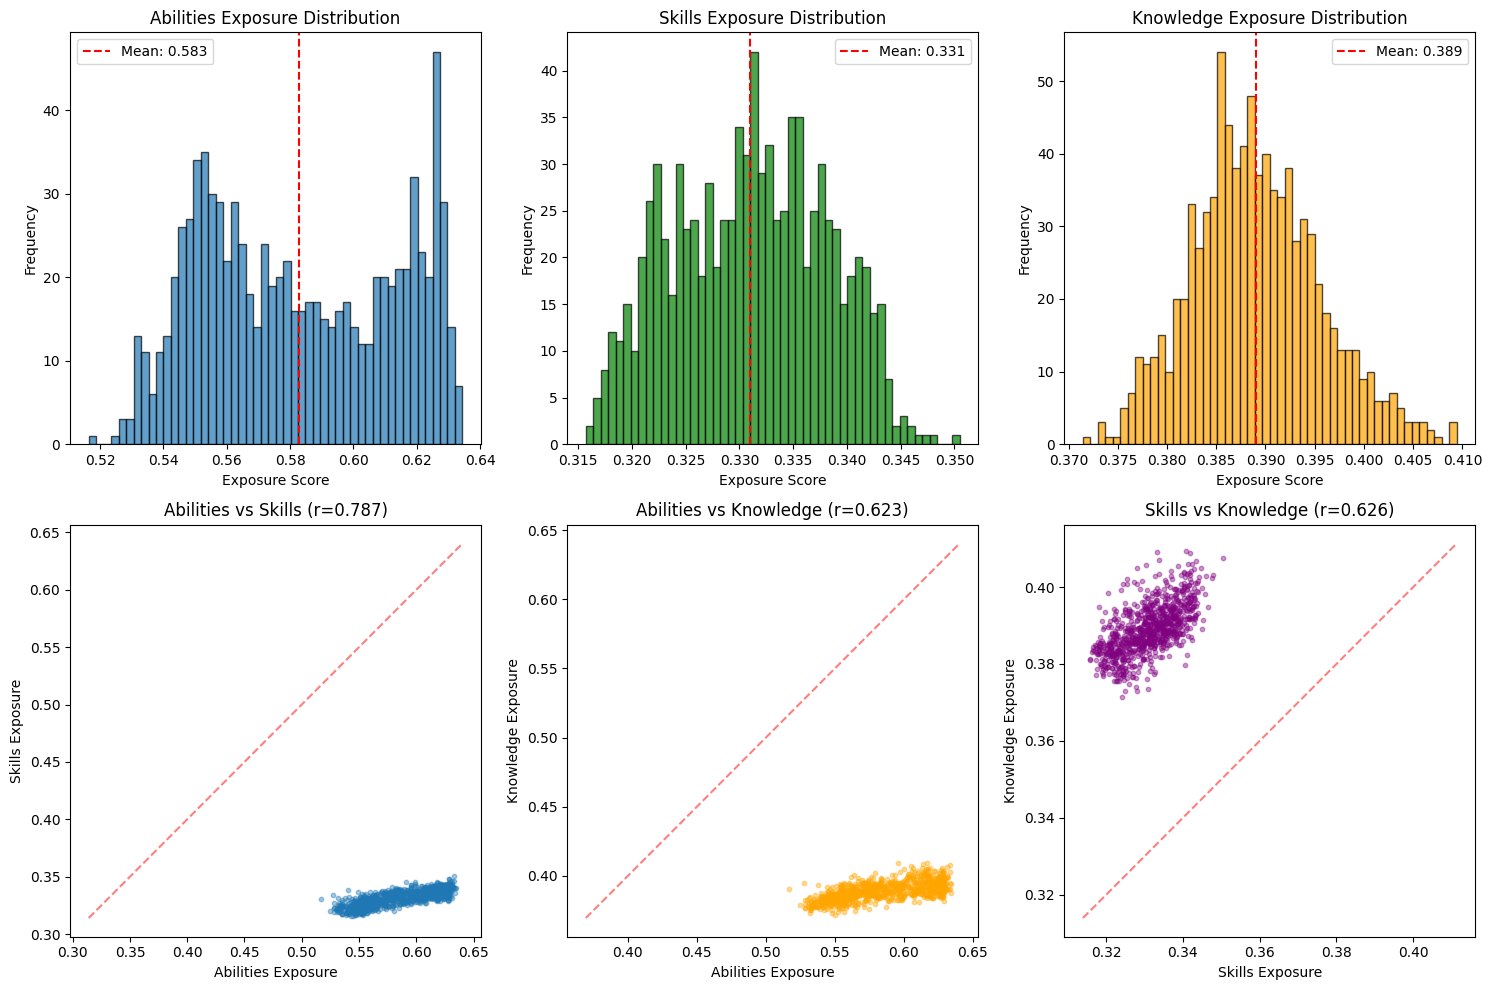


BIGGEST DIVERGENCES: Ability exposure >> Skill exposure
Education Administrators, Postsecondary            A:0.631  S:0.331  Δ:0.300
Clergy                                             A:0.628  S:0.329  Δ:0.299
Purchasing Managers                                A:0.629  S:0.330  Δ:0.299
Investment Fund Managers                           A:0.634  S:0.336  Δ:0.298
Chief Executives                                   A:0.627  S:0.330  Δ:0.297
Supply Chain Managers                              A:0.629  S:0.331  Δ:0.297
Information Technology Project Managers            A:0.630  S:0.333  Δ:0.297
Labor Relations Specialists                        A:0.628  S:0.332  Δ:0.296
Customs Brokers                                    A:0.629  S:0.334  Δ:0.295
Human Resources Managers                           A:0.626  S:0.331  Δ:0.295
Lawyers                                            A:0.630  S:0.335  Δ:0.295
Judges, Magistrate Judges, and Magistrates         A:0.634  S:0.340  Δ:0.294
Purchasing Agents, 

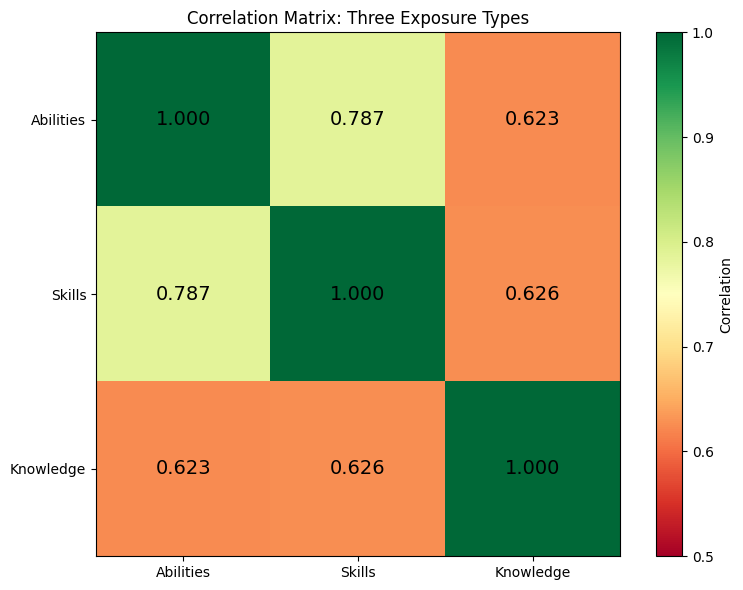

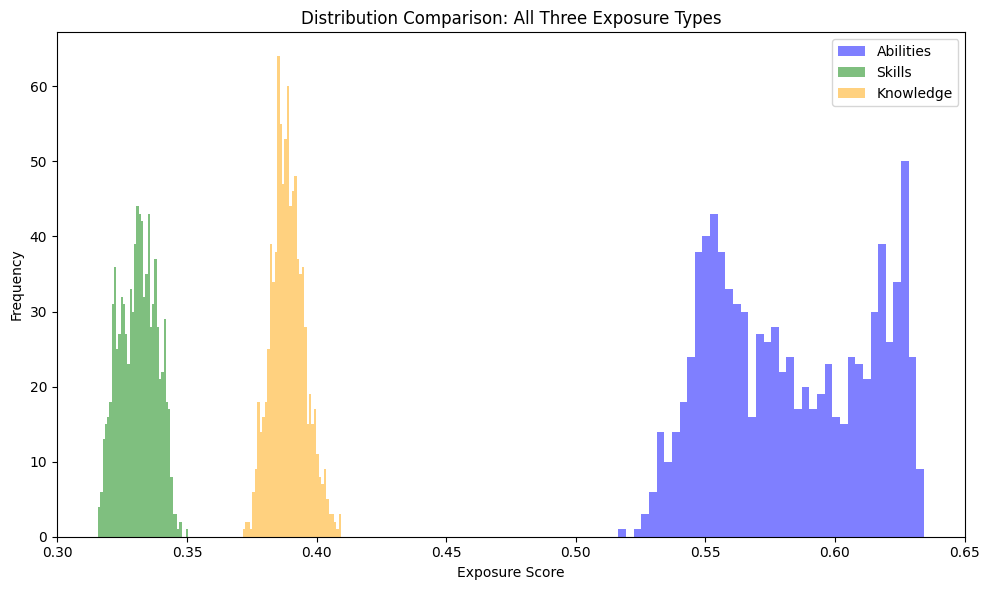

In [ ]:
# %% [markdown]
# ## Exploration: Skills and Knowledge Exposure Results

# %%
# Basic stats for all three exposure types
print("=" * 80)
print("SUMMARY STATISTICS: ALL THREE EXPOSURE TYPES")
print("=" * 80)

for name, df in [("Abilities", output_df), ("Skills", skills_output), ("Knowledge", knowledge_output)]:
    print(f"\n{name}:")
    print(f"  N occupations: {len(df)}")
    print(f"  Mean exposure: {df['exposure'].mean():.4f}")
    print(f"  Std exposure:  {df['exposure'].std():.4f}")
    print(f"  Min:           {df['exposure'].min():.4f}")
    print(f"  Max:           {df['exposure'].max():.4f}")
    print(f"  Range:         {df['exposure'].max() - df['exposure'].min():.4f}")

# %%
# Top and bottom occupations for Skills
print("\n" + "=" * 80)
print("TOP 25 OCCUPATIONS BY SKILLS EXPOSURE")
print("=" * 80)
for i, (soc, row) in enumerate(skills_output.head(25).iterrows(), 1):
    print(f"{i:3d}. {row['title'][:55]:<55} {row['exposure']:.4f}")

print("\n" + "=" * 80)
print("BOTTOM 25 OCCUPATIONS BY SKILLS EXPOSURE")
print("=" * 80)
for i, (soc, row) in enumerate(skills_output.tail(25).iterrows(), 1):
    print(f"{i:3d}. {row['title'][:55]:<55} {row['exposure']:.4f}")

# %%
# Top and bottom occupations for Knowledge
print("\n" + "=" * 80)
print("TOP 25 OCCUPATIONS BY KNOWLEDGE EXPOSURE")
print("=" * 80)
for i, (soc, row) in enumerate(knowledge_output.head(25).iterrows(), 1):
    print(f"{i:3d}. {row['title'][:55]:<55} {row['exposure']:.4f}")

print("\n" + "=" * 80)
print("BOTTOM 25 OCCUPATIONS BY KNOWLEDGE EXPOSURE")
print("=" * 80)
for i, (soc, row) in enumerate(knowledge_output.tail(25).iterrows(), 1):
    print(f"{i:3d}. {row['title'][:55]:<55} {row['exposure']:.4f}")

# %%
# Reset indices
output_df_reset = output_df.reset_index(names="soc_code") if "soc_code" not in output_df.columns else output_df.reset_index()
skills_output_reset = skills_output.reset_index(names="soc_code") if "soc_code" not in skills_output.columns else skills_output.reset_index()
knowledge_output_reset = knowledge_output.reset_index(names="soc_code") if "soc_code" not in knowledge_output.columns else knowledge_output.reset_index()

# Merge on soc_code
combined_exposure = output_df_reset[["soc_code", "title", "exposure"]].rename(columns={"exposure": "ability_exposure"})
combined_exposure = combined_exposure.merge(
    skills_output_reset[["soc_code", "exposure"]].rename(columns={"exposure": "skill_exposure"}),
    on="soc_code",
    how="inner"
)
combined_exposure = combined_exposure.merge(
    knowledge_output_reset[["soc_code", "exposure"]].rename(columns={"exposure": "knowledge_exposure"}),
    on="soc_code",
    how="inner"
)

print(f"Combined: {len(combined_exposure)} occupations")
print("\nCorrelation matrix:")
print(combined_exposure[["ability_exposure", "skill_exposure", "knowledge_exposure"]].corr().round(4))

# Correlation matrix
print("\n" + "=" * 80)
print("CORRELATION MATRIX: ABILITIES vs SKILLS vs KNOWLEDGE")
print("=" * 80)
corr_matrix = combined_exposure[["ability_exposure", "skill_exposure", "knowledge_exposure"]].corr()
print(corr_matrix.round(4))

# %%
# Plotting
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Row 1: Distributions
axes[0, 0].hist(output_df["exposure"], bins=50, edgecolor="black", alpha=0.7)
axes[0, 0].set_title("Abilities Exposure Distribution")
axes[0, 0].set_xlabel("Exposure Score")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].axvline(output_df["exposure"].mean(), color="red", linestyle="--", label=f'Mean: {output_df["exposure"].mean():.3f}')
axes[0, 0].legend()

axes[0, 1].hist(skills_output["exposure"], bins=50, edgecolor="black", alpha=0.7, color="green")
axes[0, 1].set_title("Skills Exposure Distribution")
axes[0, 1].set_xlabel("Exposure Score")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].axvline(skills_output["exposure"].mean(), color="red", linestyle="--", label=f'Mean: {skills_output["exposure"].mean():.3f}')
axes[0, 1].legend()

axes[0, 2].hist(knowledge_output["exposure"], bins=50, edgecolor="black", alpha=0.7, color="orange")
axes[0, 2].set_title("Knowledge Exposure Distribution")
axes[0, 2].set_xlabel("Exposure Score")
axes[0, 2].set_ylabel("Frequency")
axes[0, 2].axvline(knowledge_output["exposure"].mean(), color="red", linestyle="--", label=f'Mean: {knowledge_output["exposure"].mean():.3f}')
axes[0, 2].legend()

# Row 2: Scatter comparisons
axes[1, 0].scatter(combined_exposure["ability_exposure"], combined_exposure["skill_exposure"], alpha=0.4, s=10)
axes[1, 0].set_xlabel("Abilities Exposure")
axes[1, 0].set_ylabel("Skills Exposure")
axes[1, 0].set_title(f"Abilities vs Skills (r={corr_matrix.loc['ability_exposure', 'skill_exposure']:.3f})")
# Add diagonal line
lims = [min(axes[1, 0].get_xlim()[0], axes[1, 0].get_ylim()[0]), max(axes[1, 0].get_xlim()[1], axes[1, 0].get_ylim()[1])]
axes[1, 0].plot(lims, lims, 'r--', alpha=0.5, label='y=x')

axes[1, 1].scatter(combined_exposure["ability_exposure"], combined_exposure["knowledge_exposure"], alpha=0.4, s=10, color="orange")
axes[1, 1].set_xlabel("Abilities Exposure")
axes[1, 1].set_ylabel("Knowledge Exposure")
axes[1, 1].set_title(f"Abilities vs Knowledge (r={corr_matrix.loc['ability_exposure', 'knowledge_exposure']:.3f})")
lims = [min(axes[1, 1].get_xlim()[0], axes[1, 1].get_ylim()[0]), max(axes[1, 1].get_xlim()[1], axes[1, 1].get_ylim()[1])]
axes[1, 1].plot(lims, lims, 'r--', alpha=0.5, label='y=x')

axes[1, 2].scatter(combined_exposure["skill_exposure"], combined_exposure["knowledge_exposure"], alpha=0.4, s=10, color="purple")
axes[1, 2].set_xlabel("Skills Exposure")
axes[1, 2].set_ylabel("Knowledge Exposure")
axes[1, 2].set_title(f"Skills vs Knowledge (r={corr_matrix.loc['skill_exposure', 'knowledge_exposure']:.3f})")
lims = [min(axes[1, 2].get_xlim()[0], axes[1, 2].get_ylim()[0]), max(axes[1, 2].get_xlim()[1], axes[1, 2].get_ylim()[1])]
axes[1, 2].plot(lims, lims, 'r--', alpha=0.5, label='y=x')

plt.tight_layout()
plt.savefig("exposure_comparison_plots.png", dpi=150)
plt.show()

# %%
# Occupations with biggest divergence between measures
combined_exposure["ability_skill_diff"] = combined_exposure["ability_exposure"] - combined_exposure["skill_exposure"]
combined_exposure["ability_knowledge_diff"] = combined_exposure["ability_exposure"] - combined_exposure["knowledge_exposure"]
combined_exposure["skill_knowledge_diff"] = combined_exposure["skill_exposure"] - combined_exposure["knowledge_exposure"]

print("\n" + "=" * 80)
print("BIGGEST DIVERGENCES: Ability exposure >> Skill exposure")
print("=" * 80)
top_diverge = combined_exposure.nlargest(15, "ability_skill_diff")
for soc, row in top_diverge.iterrows():
    print(f"{row['title'][:50]:<50} A:{row['ability_exposure']:.3f}  S:{row['skill_exposure']:.3f}  Δ:{row['ability_skill_diff']:.3f}")

print("\n" + "=" * 80)
print("BIGGEST DIVERGENCES: Skill exposure >> Ability exposure")
print("=" * 80)
bot_diverge = combined_exposure.nsmallest(15, "ability_skill_diff")
for soc, row in bot_diverge.iterrows():
    print(f"{row['title'][:50]:<50} A:{row['ability_exposure']:.3f}  S:{row['skill_exposure']:.3f}  Δ:{row['ability_skill_diff']:.3f}")

print("\n" + "=" * 80)
print("BIGGEST DIVERGENCES: Knowledge exposure >> Ability exposure")
print("=" * 80)
bot_diverge_k = combined_exposure.nsmallest(15, "ability_knowledge_diff")
for soc, row in bot_diverge_k.iterrows():
    print(f"{row['title'][:50]:<50} A:{row['ability_exposure']:.3f}  K:{row['knowledge_exposure']:.3f}  Δ:{row['ability_knowledge_diff']:.3f}")

# %%
# Rank comparison: How much do rankings change?
combined_exposure["ability_rank"] = combined_exposure["ability_exposure"].rank(ascending=False)
combined_exposure["skill_rank"] = combined_exposure["skill_exposure"].rank(ascending=False)
combined_exposure["knowledge_rank"] = combined_exposure["knowledge_exposure"].rank(ascending=False)
combined_exposure["rank_change_skill"] = combined_exposure["ability_rank"] - combined_exposure["skill_rank"]
combined_exposure["rank_change_knowledge"] = combined_exposure["ability_rank"] - combined_exposure["knowledge_rank"]

print("\n" + "=" * 80)
print("RANK CHANGES: Ability → Skills (positive = ranked higher in abilities)")
print("=" * 80)
print("\nBiggest rank drops (high ability rank, low skill rank):")
for soc, row in combined_exposure.nlargest(10, "rank_change_skill").iterrows():
    print(f"  {row['title'][:45]:<45} A_rank:{int(row['ability_rank']):3d} → S_rank:{int(row['skill_rank']):3d} (Δ{int(row['rank_change_skill']):+4d})")

print("\nBiggest rank gains (low ability rank, high skill rank):")
for soc, row in combined_exposure.nsmallest(10, "rank_change_skill").iterrows():
    print(f"  {row['title'][:45]:<45} A_rank:{int(row['ability_rank']):3d} → S_rank:{int(row['skill_rank']):3d} (Δ{int(row['rank_change_skill']):+4d})")

# %%
# Combined weighted exposure (equal weights)
combined_exposure["combined_equal"] = (
    combined_exposure["ability_exposure"] + 
    combined_exposure["skill_exposure"] + 
    combined_exposure["knowledge_exposure"]
) / 3

print("\n" + "=" * 80)
print("TOP 25 BY COMBINED EXPOSURE (equal weights)")
print("=" * 80)
combined_sorted = combined_exposure.sort_values("combined_equal", ascending=False)
for i, (soc, row) in enumerate(combined_sorted.head(25).iterrows(), 1):
    print(f"{i:3d}. {row['title'][:45]:<45} Combined:{row['combined_equal']:.4f} (A:{row['ability_exposure']:.3f} S:{row['skill_exposure']:.3f} K:{row['knowledge_exposure']:.3f})")

# %%
# Heatmap of correlations
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix.values, cmap="RdYlGn", vmin=0.5, vmax=1.0)

# Labels
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(["Abilities", "Skills", "Knowledge"])
ax.set_yticklabels(["Abilities", "Skills", "Knowledge"])

# Add correlation values
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{corr_matrix.values[i, j]:.3f}", ha="center", va="center", fontsize=14)

ax.set_title("Correlation Matrix: Three Exposure Types")
plt.colorbar(im, ax=ax, label="Correlation")
plt.tight_layout()
plt.savefig("exposure_correlation_heatmap.png", dpi=150)
plt.show()

# %%
# Overlaid histograms
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(output_df["exposure"], bins=40, alpha=0.5, label="Abilities", color="blue")
ax.hist(skills_output["exposure"], bins=40, alpha=0.5, label="Skills", color="green")
ax.hist(knowledge_output["exposure"], bins=40, alpha=0.5, label="Knowledge", color="orange")
ax.set_xlabel("Exposure Score")
ax.set_ylabel("Frequency")
ax.set_title("Distribution Comparison: All Three Exposure Types")
ax.legend()
plt.tight_layout()
plt.savefig("exposure_distributions_overlay.png", dpi=150)
plt.show()